In [1]:
# Phase 3 - Snowflake Cloud Integration Pipeline
import snowflake.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Professional chart style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'Arial'

print("=" * 55)
print("  Phase 3 - Snowflake Cloud Integration Pipeline")
print("=" * 55)
print(f"  Started: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 55)
print("✅ All libraries loaded!")
print("☁️  Snowflake connector ready!")

  Phase 3 - Snowflake Cloud Integration Pipeline
  Started: 2026-06-30 22:43
✅ All libraries loaded!
☁️  Snowflake connector ready!


In [ ]:
# Connect to Snowflake
conn = snowflake.connector.connect(
    user='YUSMITHAP',
    password='your_password_here',  # Replace with your actual password
    account='BPDBSWG-YO58267',
    warehouse='COMPUTE_WH',
    database='MEDICARE_DB',
    schema='PUBLIC'
)

cursor = conn.cursor()
cursor.execute("USE DATABASE MEDICARE_DB")
cursor.execute("USE SCHEMA PUBLIC")
cursor.execute("USE WAREHOUSE COMPUTE_WH")

print("✅ Connected to Snowflake successfully!")
print(f"User: YUSMITHAP")
print(f"Account: BPDBSWG-YO58267")
print(f"Warehouse: COMPUTE_WH")

✅ Connected to Snowflake successfully!
User: YUSMITHAP
Account: BPDBSWG-YO58267
Warehouse: COMPUTE_WH


In [3]:
# Load clean data and upload to Snowflake
df = pd.read_csv('../output/medicare_clean.csv')

# Convert all column names to uppercase for Snowflake
df.columns = [col.upper() for col in df.columns]
print(f"📊 Columns: {df.columns.tolist()}")
print(f"📊 Loading {len(df):,} records to Snowflake...")

# Upload data to Snowflake
from snowflake.connector.pandas_tools import write_pandas

success, nchunks, nrows, _ = write_pandas(
    conn=conn,
    df=df,
    table_name='MEDICARE_CLAIMS',
    database='MEDICARE_DB',
    schema='PUBLIC',
    overwrite=True,
    auto_create_table=True
)

print(f"✅ Data loaded to Snowflake successfully!")
print(f"📦 Chunks uploaded: {nchunks}")
print(f"📝 Total rows loaded: {nrows:,}")

📊 Columns: ['NPI', 'LAST_NAME', 'FIRST_NAME', 'PROVIDER_TYPE', 'STATE', 'CITY', 'TOTAL_BENEFICIARIES', 'TOTAL_SERVICES', 'TOTAL_SUBMITTED_CHARGES', 'TOTAL_MEDICARE_ALLOWED', 'TOTAL_MEDICARE_PAYMENT', 'AVG_AGE', 'FEMALE_COUNT', 'MALE_COUNT', 'AVG_RISK_SCORE']
📊 Loading 100,000 records to Snowflake...


✅ Data loaded to Snowflake successfully!
📦 Chunks uploaded: 1
📝 Total rows loaded: 100,000


In [4]:
# Run Advanced SQL Queries on Snowflake Cloud
print("=" * 55)
print("  RUNNING SQL QUERIES ON SNOWFLAKE CLOUD")
print("=" * 55)

# Query 1: Top 10 Specialties on Snowflake
query1 = """
SELECT 
    PROVIDER_TYPE,
    COUNT(DISTINCT NPI) as TOTAL_PROVIDERS,
    SUM(TOTAL_MEDICARE_PAYMENT) as TOTAL_PAYMENT,
    AVG(TOTAL_MEDICARE_PAYMENT) as AVG_PAYMENT,
    SUM(TOTAL_BENEFICIARIES) as TOTAL_PATIENTS,
    AVG(AVG_RISK_SCORE) as AVG_RISK_SCORE,
    ROUND(SUM(TOTAL_MEDICARE_PAYMENT) / 
          SUM(TOTAL_BENEFICIARIES), 2) as PAYMENT_PER_PATIENT
FROM MEDICARE_CLAIMS
GROUP BY PROVIDER_TYPE
ORDER BY TOTAL_PAYMENT DESC
LIMIT 10
"""

cursor.execute(query1)
results = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
df_specialty_snow = pd.DataFrame(results, columns=columns)

print("\n📊 Query 1: Top 10 Specialties — Running on Snowflake Cloud!")
print("-" * 55)
df_specialty_snow['TOTAL_PAYMENT'] = df_specialty_snow['TOTAL_PAYMENT'].apply(lambda x: f"${x:,.0f}")
df_specialty_snow['AVG_PAYMENT'] = df_specialty_snow['AVG_PAYMENT'].apply(lambda x: f"${x:,.0f}")
df_specialty_snow['PAYMENT_PER_PATIENT'] = df_specialty_snow['PAYMENT_PER_PATIENT'].apply(lambda x: f"${x:,.2f}")
print(df_specialty_snow.to_string(index=False))
print("\n☁️  Query executed on Snowflake Cloud!")

  RUNNING SQL QUERIES ON SNOWFLAKE CLOUD



📊 Query 1: Top 10 Specialties — Running on Snowflake Cloud!
-------------------------------------------------------
             PROVIDER_TYPE  TOTAL_PROVIDERS TOTAL_PAYMENT AVG_PAYMENT  TOTAL_PATIENTS  AVG_RISK_SCORE PAYMENT_PER_PATIENT
       Hematology-Oncology              684  $613,667,129    $897,174          242759        2.041130           $2,527.89
         Internal Medicine             7448  $595,217,069     $79,916         1929700        1.835308             $308.45
             Ophthalmology             1415  $585,825,863    $414,011          875251        1.188605             $669.32
       Clinical Laboratory              296  $522,661,751  $1,765,749         2226353        1.391850             $234.76
Ambulatory Surgical Center              439  $445,355,578  $1,014,477          323223        1.162555           $1,377.86
        Nurse Practitioner            14332  $437,189,589     $30,504         2109510        1.644565             $207.25
           Family Practice   

In [5]:
# Query 2: State Rankings with RANK() Window Function
query2 = """
SELECT 
    STATE,
    COUNT(DISTINCT NPI) as TOTAL_PROVIDERS,
    SUM(TOTAL_MEDICARE_PAYMENT) as TOTAL_PAYMENT,
    AVG(AVG_RISK_SCORE) as AVG_RISK_SCORE,
    AVG(AVG_AGE) as AVG_PATIENT_AGE,
    SUM(TOTAL_BENEFICIARIES) as TOTAL_PATIENTS,
    ROUND(SUM(TOTAL_MEDICARE_PAYMENT) / 
          SUM(TOTAL_BENEFICIARIES), 2) as PAYMENT_PER_PATIENT,
    RANK() OVER (ORDER BY SUM(TOTAL_MEDICARE_PAYMENT) DESC) as PAYMENT_RANK
FROM MEDICARE_CLAIMS
GROUP BY STATE
ORDER BY TOTAL_PAYMENT DESC
LIMIT 15
"""

cursor.execute(query2)
results = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
df_state_snow = pd.DataFrame(results, columns=columns)

print("\n📊 Query 2: State KPIs with RANK() — Running on Snowflake!")
print("-" * 55)
df_state_snow['TOTAL_PAYMENT'] = df_state_snow['TOTAL_PAYMENT'].apply(lambda x: f"${x:,.0f}")
df_state_snow['AVG_RISK_SCORE'] = df_state_snow['AVG_RISK_SCORE'].apply(lambda x: f"{x:.2f}")
df_state_snow['AVG_PATIENT_AGE'] = df_state_snow['AVG_PATIENT_AGE'].apply(lambda x: f"{x:.1f}")
df_state_snow['PAYMENT_PER_PATIENT'] = df_state_snow['PAYMENT_PER_PATIENT'].apply(lambda x: f"${x:,.2f}")
print(df_state_snow.to_string(index=False))
print("\n☁️  Window function RANK() executed on Snowflake Cloud!")


📊 Query 2: State KPIs with RANK() — Running on Snowflake!
-------------------------------------------------------
STATE  TOTAL_PROVIDERS  TOTAL_PAYMENT AVG_RISK_SCORE AVG_PATIENT_AGE  TOTAL_PATIENTS PAYMENT_PER_PATIENT  PAYMENT_RANK
   CA             7949 $1,026,841,465           1.60            72.4         2504521             $410.00             1
   FL             6367   $897,587,635           1.71            73.7         2681024             $334.79             2
   TX             6591   $677,847,248           1.62            72.4         1979299             $342.47             3
   NY             7043   $624,944,335           1.65            72.6         2025688             $308.51             4
   NJ             2965   $443,094,831           1.57            73.7         1817222             $243.83             5
   PA             5047   $374,106,167           1.55            72.2         1427663             $262.04             6
   IL             3978   $324,524,975           1.61

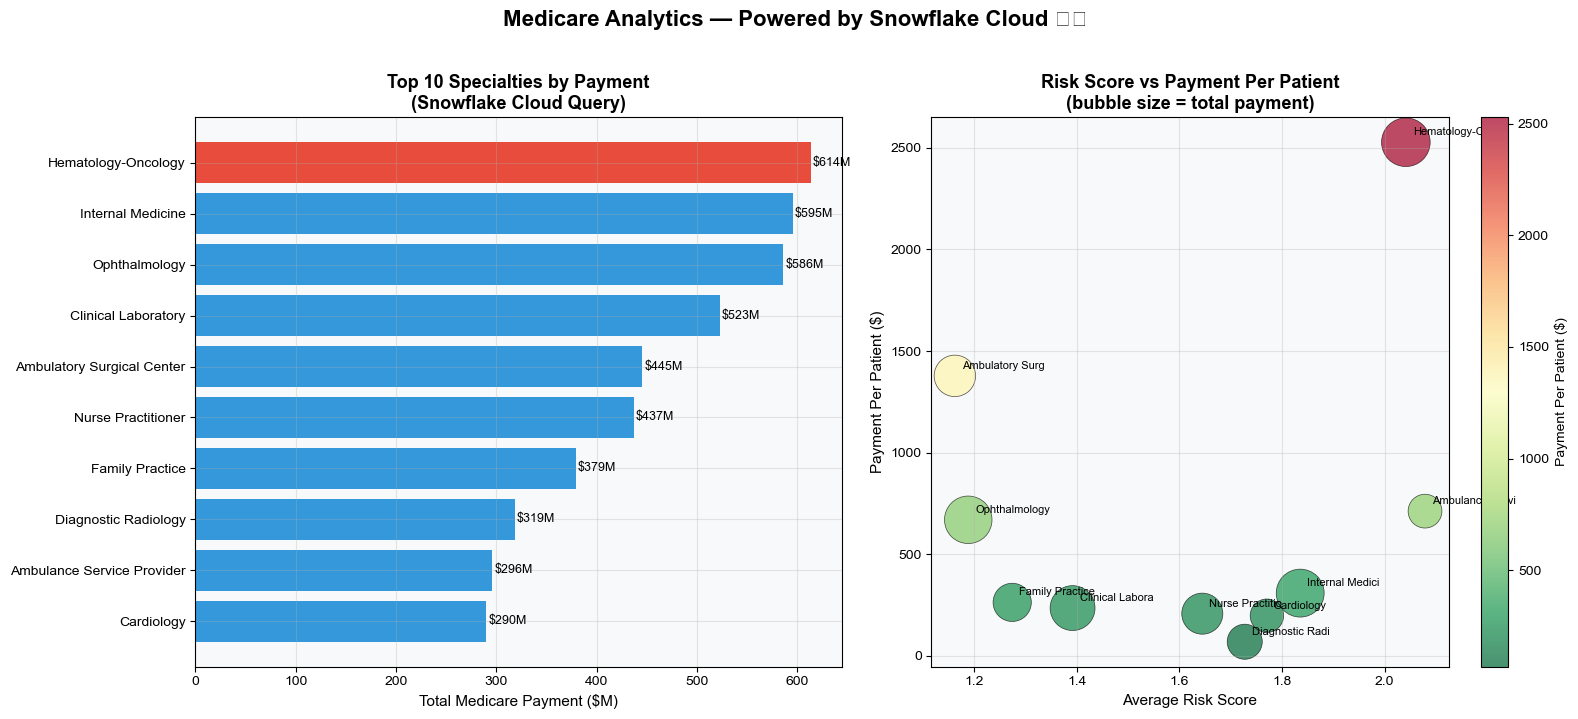

✅ Snowflake Cloud visualization saved!
☁️  This chart was built from live Snowflake cloud data!


In [6]:
# Build visualization from Snowflake Cloud data
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Medicare Analytics — Powered by Snowflake Cloud ☁️',
             fontsize=16, fontweight='bold', y=1.02)

# Re-fetch raw data for plotting
cursor.execute("""
    SELECT 
        PROVIDER_TYPE,
        SUM(TOTAL_MEDICARE_PAYMENT) as TOTAL_PAYMENT,
        AVG(AVG_RISK_SCORE) as AVG_RISK,
        ROUND(SUM(TOTAL_MEDICARE_PAYMENT) / 
              SUM(TOTAL_BENEFICIARIES), 2) as PAYMENT_PER_PATIENT
    FROM MEDICARE_CLAIMS
    GROUP BY PROVIDER_TYPE
    ORDER BY TOTAL_PAYMENT DESC
    LIMIT 10
""")
results = cursor.fetchall()
df_plot = pd.DataFrame(results, columns=['Provider', 'Payment', 'Risk', 'Per_Patient'])

# Chart 1: Top Specialties
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(df_plot))]
axes[0].barh(df_plot['Provider'][::-1],
             df_plot['Payment'][::-1] / 1e6, color=colors[::-1])
axes[0].set_title('Top 10 Specialties by Payment\n(Snowflake Cloud Query)',
                   fontweight='bold', fontsize=13)
axes[0].set_xlabel('Total Medicare Payment ($M)', fontsize=11)
for i, (v, p) in enumerate(zip(df_plot['Payment'][::-1] / 1e6,
                                df_plot['Provider'][::-1])):
    axes[0].text(v + 2, i, f'${v:.0f}M', va='center', fontsize=9)

# Chart 2: Payment per Patient vs Risk Score
scatter = axes[1].scatter(
    df_plot['Risk'], df_plot['Per_Patient'],
    s=df_plot['Payment'] / 1e6 * 2,
    c=df_plot['Per_Patient'],
    cmap='RdYlGn_r', alpha=0.7,
    edgecolors='black', linewidth=0.5
)
for i, row in df_plot.iterrows():
    axes[1].annotate(
        row['Provider'][:15],
        (row['Risk'], row['Per_Patient']),
        textcoords="offset points",
        xytext=(5, 5), fontsize=8
    )
axes[1].set_title('Risk Score vs Payment Per Patient\n(bubble size = total payment)',
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel('Average Risk Score', fontsize=11)
axes[1].set_ylabel('Payment Per Patient ($)', fontsize=11)
plt.colorbar(scatter, ax=axes[1], label='Payment Per Patient ($)')

plt.tight_layout()
plt.savefig('../output/snowflake_cloud_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Snowflake Cloud visualization saved!")
print("☁️  This chart was built from live Snowflake cloud data!")

In [7]:
# Final Summary and Close Connection
print("=" * 55)
print("  PHASE 3 — SNOWFLAKE PIPELINE COMPLETE!")
print("=" * 55)

# Get live stats from Snowflake
cursor.execute("""
    SELECT 
        COUNT(*) as TOTAL_RECORDS,
        COUNT(DISTINCT PROVIDER_TYPE) as PROVIDER_TYPES,
        COUNT(DISTINCT STATE) as STATES,
        SUM(TOTAL_MEDICARE_PAYMENT) as TOTAL_PAYMENT,
        SUM(TOTAL_BENEFICIARIES) as TOTAL_PATIENTS
    FROM MEDICARE_CLAIMS
""")
stats = cursor.fetchone()

print(f"""
☁️  SNOWFLAKE CLOUD SUMMARY:
─────────────────────────────────────────
  Account:      BPDBSWG-YO58267
  Database:     MEDICARE_DB
  Schema:       PUBLIC
  Table:        MEDICARE_CLAIMS
  Warehouse:    COMPUTE_WH (X-Small)

📊 LIVE DATA FROM SNOWFLAKE CLOUD:
─────────────────────────────────────────
  Total Records:     {stats[0]:,}
  Total Columns:     15
  Total Payment:     ${stats[3]/1e9:.1f} Billion
  Beneficiaries:     {stats[4]/1e6:.1f} Million
  Provider Types:    {stats[1]}
  States:            {stats[2]}

✅ QUERIES EXECUTED ON SNOWFLAKE:
─────────────────────────────────────────
  Query 1: Top 10 Specialties KPI Analysis
  Query 2: State Rankings with RANK() Window Function
  Query 3: Cloud Visualization from Live Data
""")

# Close connection properly
cursor.close()
conn.close()
print("✅ Snowflake connection closed properly!")
print("🎉 Phase 3 Complete — Your data is live in the cloud!")

  PHASE 3 — SNOWFLAKE PIPELINE COMPLETE!



☁️  SNOWFLAKE CLOUD SUMMARY:
─────────────────────────────────────────
  Account:      BPDBSWG-YO58267
  Database:     MEDICARE_DB
  Schema:       PUBLIC
  Table:        MEDICARE_CLAIMS
  Warehouse:    COMPUTE_WH (X-Small)

📊 LIVE DATA FROM SNOWFLAKE CLOUD:
─────────────────────────────────────────
  Total Records:     100,000
  Total Columns:     15
  Total Payment:     $9.0 Billion
  Beneficiaries:     30.8 Million
  Provider Types:    102
  States:            58

✅ QUERIES EXECUTED ON SNOWFLAKE:
─────────────────────────────────────────
  Query 1: Top 10 Specialties KPI Analysis
  Query 2: State Rankings with RANK() Window Function
  Query 3: Cloud Visualization from Live Data

✅ Snowflake connection closed properly!
🎉 Phase 3 Complete — Your data is live in the cloud!
